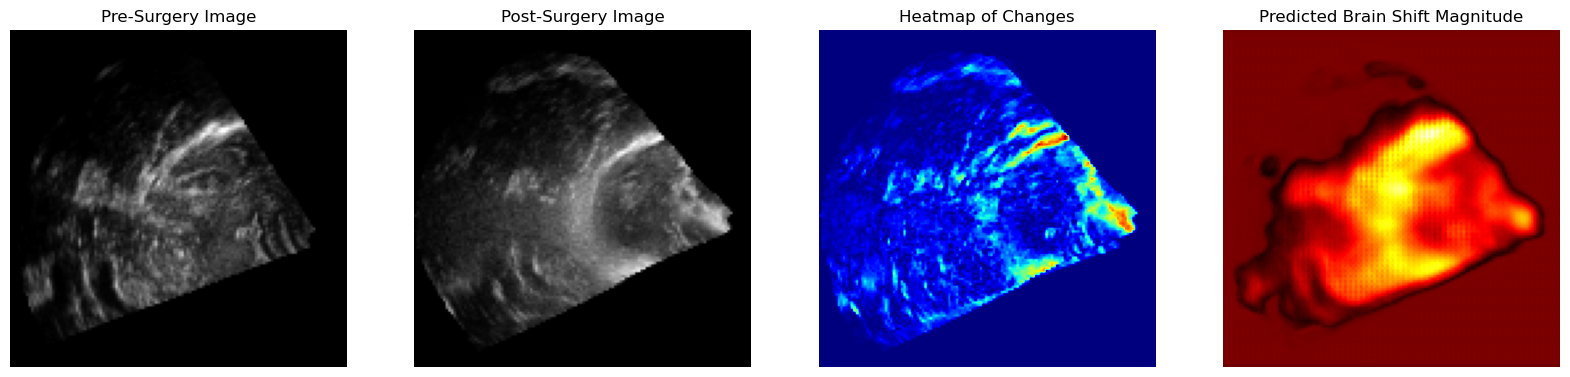

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load CSV
test_patient = "14"  # Change this as needed
csv_path = f"brainshift_vector_output/test_patient_{test_patient}.csv"
df = pd.read_csv(csv_path)

# Convert back to 2D
shape = (128, 128)  # Assuming slices are 128x128
pre_slice = df["pre_slice"].values.reshape(shape)
post_slice = df["post_slice"].values.reshape(shape)
diff_image = df["diff_image"].values.reshape(shape)
predicted_shift = df["predicted_shift"].values.reshape(shape)

# Plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(pre_slice, cmap='gray')
axs[0].set_title("Pre-Surgery Image")
axs[0].axis("off")

axs[1].imshow(post_slice, cmap='gray')
axs[1].set_title("Post-Surgery Image")
axs[1].axis("off")

axs[2].imshow(diff_image, cmap='jet')
axs[2].set_title("Heatmap of Changes")
axs[2].axis("off")

axs[3].imshow(predicted_shift, cmap='hot')
axs[3].set_title("Predicted Brain Shift Magnitude")
axs[3].axis("off")

plt.show()


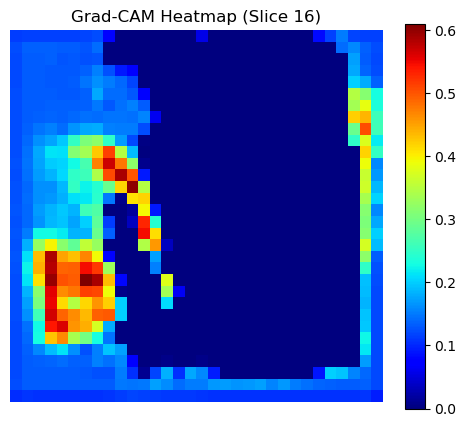

In [53]:
import numpy as np
import matplotlib.pyplot as plt
# Model Explainability
test_patient = "14"  # Change this as needed

# Load the Grad-CAM 3D volume
cam_np = np.load(f"model_explainability/gradcam_volume_{test_patient}.npy")

# Choose a slice to visualize (e.g., middle slice)
mid_slice = cam_np.shape[0] // 2

plt.figure(figsize=(6, 5))
plt.imshow(cam_np[mid_slice], cmap="jet")
plt.title(f"Grad-CAM Heatmap (Slice {mid_slice})")
plt.axis("off")
plt.colorbar()
plt.show()


In [54]:
# import matplotlib.pyplot as plt
# from matplotlib.widgets import Slider
#
#
#
# Set up figure and initial plot
# fig, ax = plt.subplots()
# plt.subplots_adjust(bottom=0.2)
# slice_idx = cam_np.shape[0] // 2
# img = ax.imshow(cam_np[slice_idx], cmap='jet')
# plt.colorbar(img)
# ax.set_title(f"Grad-CAM Slice {slice_idx}")
#
# Add slider
# ax_slider = plt.axes([0.25, 0.05, 0.5, 0.03])
# slider = Slider(ax_slider, 'Slice', 0, cam_np.shape[0] - 1, valinit=slice_idx, valstep=1)
#
# def update(val):
#    idx = int(slider.val)
#    img.set_data(cam_np[idx])
#    ax.set_title(f"Grad-CAM Slice {idx}")
#    fig.canvas.draw_idle()
#
# slider.on_changed(update)
# plt.show()


In [55]:
import os
import matplotlib.pyplot as plt
import numpy as np

output_dir = "model_explainability/gradcam_slices"
os.makedirs(output_dir, exist_ok=True)

for i in range(cam_np.shape[0]):
    plt.imshow(cam_np[i], cmap="jet")
    plt.axis("off")
    plt.title(f"Grad-CAM Slice {i}")
    plt.savefig(f"{output_dir}/slice_{i:03}.png", bbox_inches='tight')
    plt.close()

print(f"✅ Saved {cam_np.shape[0]} heatmap slices to: {output_dir}/")


✅ Saved 32 heatmap slices to: model_explainability/gradcam_slices/


In [56]:
import nibabel as nib

# Replace with actual affine if you have it
affine = np.eye(4)  # Identity for default spacing/origin

nifti_img = nib.Nifti1Image(cam_np, affine)
nib.save(nifti_img, f"model_explainability/nifti_image/gradcam_volume_{test_patient}.nii.gz")

print("✅ Grad-CAM exported as NIfTI: gradcam_volume.nii.gz")


✅ Grad-CAM exported as NIfTI: gradcam_volume.nii.gz


In [64]:
import napari
import numpy as np
# Interactive Visualization with Napari



viewer = napari.Viewer()
viewer.add_image(cam_np, name="Grad-CAM", colormap="inferno")
napari.run()


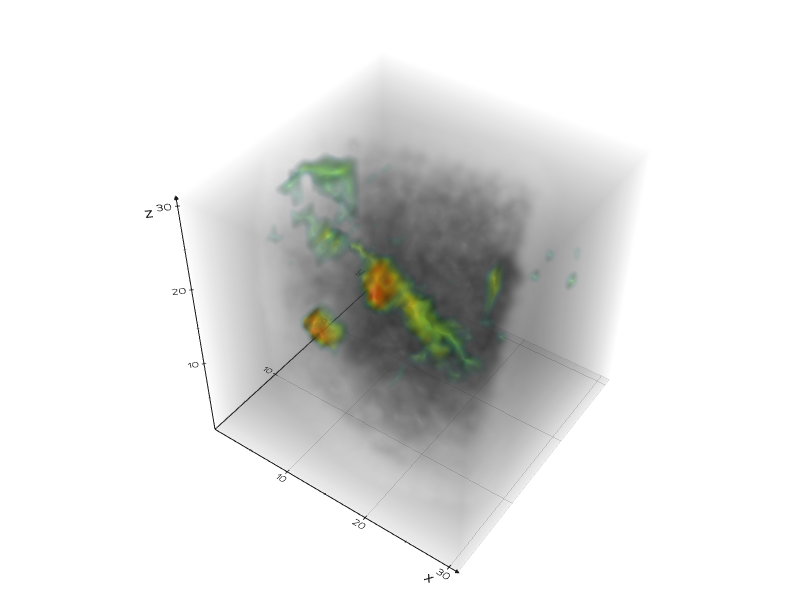

In [81]:
from vedo import Volume, show, Plotter
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

# Load Grad-CAM volume
cam_np = np.load(f"model_explainability/gradcam_volume_{test_patient}.npy")
thresholded_cam = np.where(cam_np > 0.5, cam_np, 0)

# Load and normalize pre-op ultrasound
pre_img = nib.load(f"Training Dataset/{test_patient}/pre.mnc").get_fdata()
pre_img = (pre_img - pre_img.min()) / (pre_img.max() - pre_img.min())

# Resize ultrasound to match Grad-CAM volume
scale_factors = [cam_np.shape[i] / pre_img.shape[i] for i in range(3)]
pre_resized = zoom(pre_img, scale_factors)

# Create vedo volumes
us_vol = Volume(pre_resized).cmap("gray").alpha([0, 0.1, 0.2, 0.5])
cam_vol = Volume(thresholded_cam).cmap("jet").alpha([0, 0, 0.2, 0.8, 1])

# Create a plotter with a better camera position
plotter = Plotter(bg='white')
plotter.show(us_vol, cam_vol, axes=1, viewup='z', zoom=1, interactive=True)


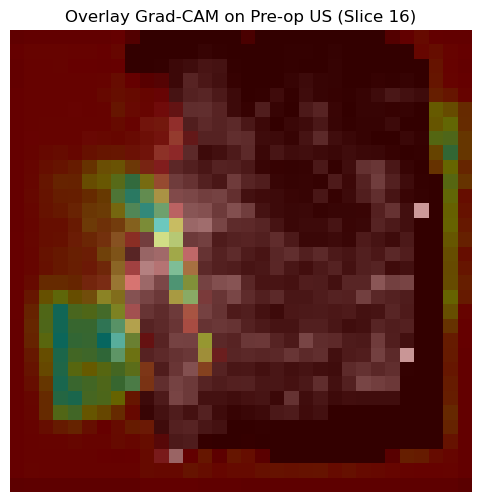

In [66]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load original US (pre-op) as Numpy
pre_img = nib.load(f"Training dataset/{test_patient}/pre.mnc").get_fdata()
pre_img_resized = np.interp(pre_img, (pre_img.min(), pre_img.max()), (0, 1))  # Normalize

# Resize to match cam_np (128,128,128) if needed
from scipy.ndimage import zoom
scale_factors = [cam_np.shape[i] / pre_img.shape[i] for i in range(3)]
pre_resized = zoom(pre_img_resized, scale_factors)

# Choose slice
mid_slice = cam_np.shape[0] // 2
us_slice = pre_resized[mid_slice]  # Grayscale
cam_slice = cam_np[mid_slice]      # Heatmap

# Convert grayscale to RGB
us_rgb = cv2.cvtColor((us_slice * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

# Apply heatmap using OpenCV
heatmap = cv2.applyColorMap((cam_slice * 255).astype(np.uint8), cv2.COLORMAP_JET)

# Blend both (alpha blending)
overlay = cv2.addWeighted(us_rgb, 0.6, heatmap, 0.4, 0)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Overlay Grad-CAM on Pre-op US (Slice {mid_slice})")
plt.axis("off")
plt.show()


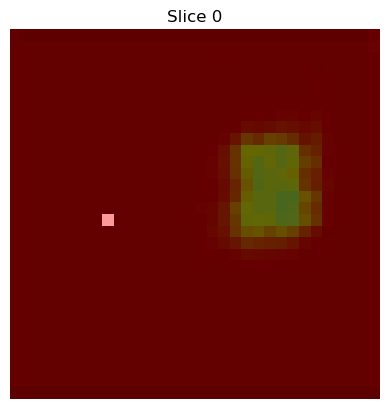

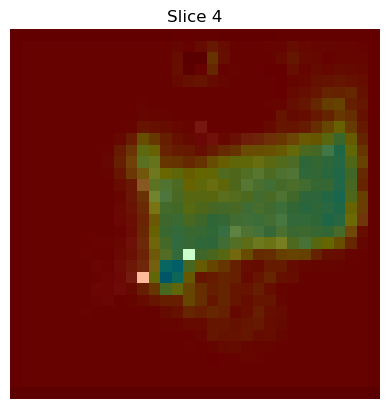

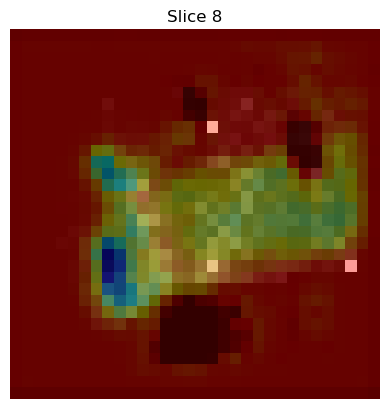

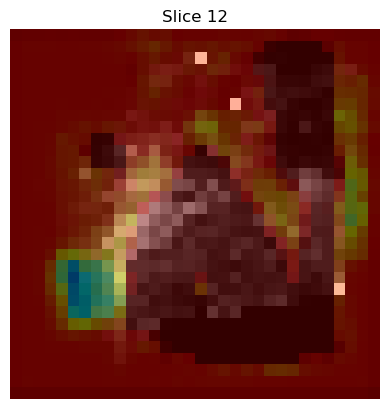

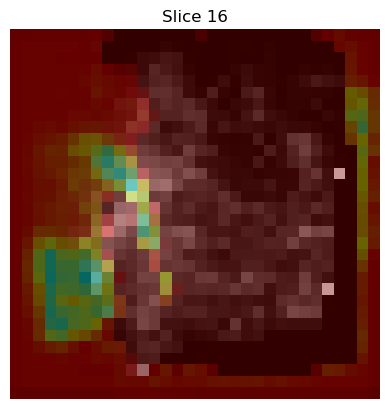

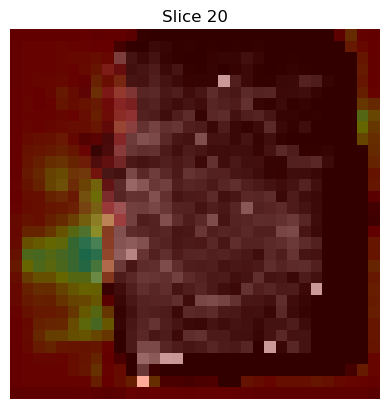

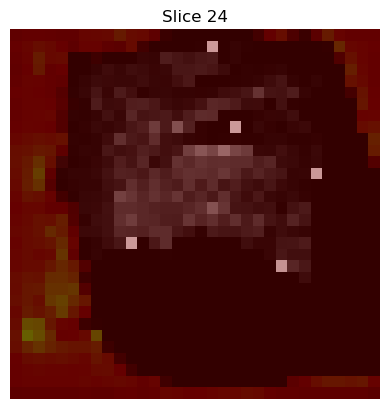

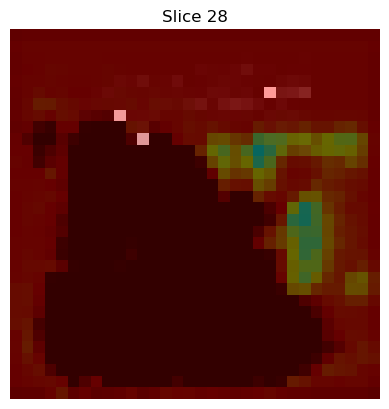

In [67]:
for i in range(0, cam_np.shape[0], 4):  # every 4th slice
    cam_slice = cam_np[i]
    us_slice = pre_resized[i]

    us_rgb = cv2.cvtColor((us_slice * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    heatmap = cv2.applyColorMap((cam_slice * 255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(us_rgb, 0.6, heatmap, 0.4, 0)

    plt.imshow(overlay)
    plt.title(f"Slice {i}")
    plt.axis("off")
    plt.show()


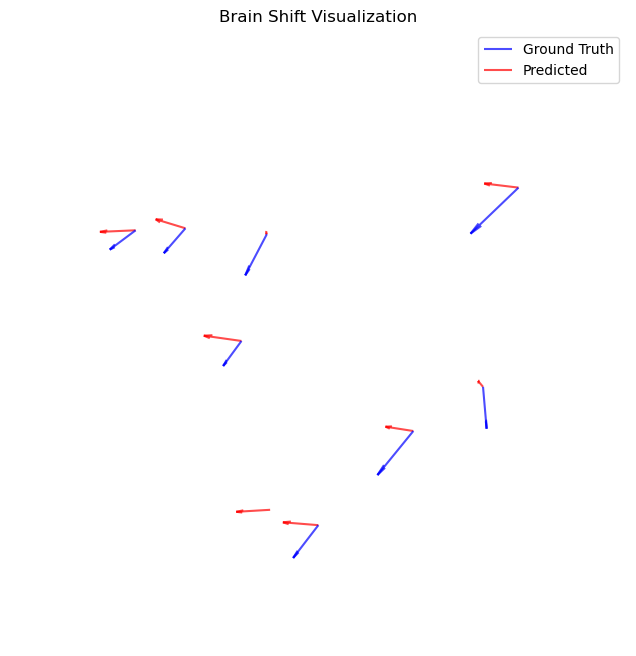

In [95]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import nibabel as nib
from nilearn import plotting

# Load CSV
test_patient = '03'
df = pd.read_csv(f'brainshiftvectors/brain_shift_vectors_test{test_patient}.csv')

# Load brain US 
brain_img = nib.load(f"Training Dataset/{test_patient}/pre.mnc")  # Use your pre-op brain scan

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot ground-truth vectors (in blue)
ax.quiver(df["X"], df["Y"], df["Z"], df["GT_U"], df["GT_V"], df["GT_W"], 
          color='blue', label="Ground Truth", alpha=0.7, arrow_length_ratio=0.2)

# Plot predicted vectors (in red)
ax.quiver(df["X"], df["Y"], df["Z"], df["Pred_U"], df["Pred_V"], df["Pred_W"], 
          color='red', label="Predicted", alpha=0.7, arrow_length_ratio=0.2)

plotting.plot_glass_brain(brain_img, display_mode='ortho', axes=ax, alpha=0.3)

# Labels
ax.set_xlabel("X (Voxel)")
ax.set_ylabel("Y (Voxel)")
ax.set_zlabel("Z (Voxel)")
ax.set_title("Brain Shift Visualization")
ax.legend()

plt.show()


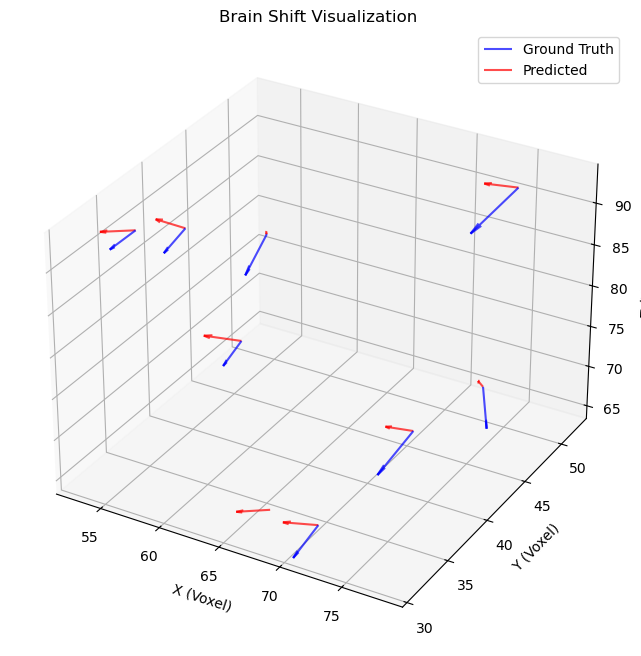

In [96]:
# WITH AXES
# figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot ground-truth vectors (blue)
ax.quiver(df["X"], df["Y"], df["Z"], df["GT_U"], df["GT_V"], df["GT_W"], 
          color='blue', label="Ground Truth", alpha=0.7, arrow_length_ratio=0.2)

# Plot predicted vectors (red)
ax.quiver(df["X"], df["Y"], df["Z"], df["Pred_U"], df["Pred_V"], df["Pred_W"], 
          color='red', label="Predicted", alpha=0.7, arrow_length_ratio=0.2)

# Labels
ax.set_xlabel("X (Voxel)")
ax.set_ylabel("Y (Voxel)")
ax.set_zlabel("Z (Voxel)")
ax.set_title("Brain Shift Visualization")
ax.legend()

plt.show()

In [88]:
# Load CSV
test_patient = '14'
df = pd.read_csv(f'brainshiftvectors/brain_shift_vectors_test{test_patient}.csv')


df.columns

Index(['X', 'Y', 'Z', 'GT_U', 'GT_V', 'GT_W', 'Pred_U', 'Pred_V', 'Pred_W'], dtype='object')

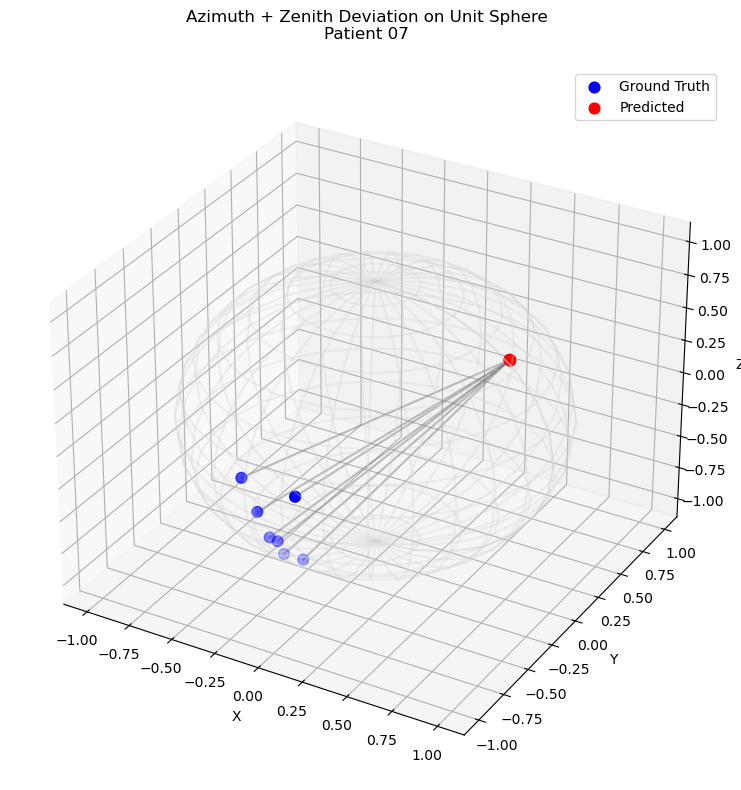

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load data
test_patient = '07'
df = pd.read_csv(f'brainshiftvectors/brain_shift_vectors_test{test_patient}.csv')

# Extract GT and Pred vectors
gt = df[['GT_U', 'GT_V', 'GT_W']].values
pred = df[['Pred_U', 'Pred_V', 'Pred_W']].values

# Normalize to unit vectors
gt_norm = gt / (np.linalg.norm(gt, axis=1, keepdims=True) + 1e-6)
pred_norm = pred / (np.linalg.norm(pred, axis=1, keepdims=True) + 1e-6)

# Convert to azimuth and zenith (in radians)
def cartesian_to_spherical(vecs):
    x, y, z = vecs[:,0], vecs[:,1], vecs[:,2]
    r = np.linalg.norm(vecs, axis=1)
    azimuth = np.arctan2(y, x)             # angle from x-axis in XY plane
    zenith = np.arccos(z / (r + 1e-6))      # angle from Z axis
    return azimuth, zenith

az_gt, zen_gt = cartesian_to_spherical(gt_norm)
az_pred, zen_pred = cartesian_to_spherical(pred_norm)

# Convert spherical → Cartesian for plotting
def spherical_to_cartesian(az, zen):
    x = np.sin(zen) * np.cos(az)
    y = np.sin(zen) * np.sin(az)
    z = np.cos(zen)
    return x, y, z

gt_x, gt_y, gt_z = spherical_to_cartesian(az_gt, zen_gt)
pr_x, pr_y, pr_z = spherical_to_cartesian(az_pred, zen_pred)

# Plot on sphere
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Sphere surface (faint wireframe for reference)
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
x_sphere = np.cos(u)*np.sin(v)
y_sphere = np.sin(u)*np.sin(v)
z_sphere = np.cos(v)
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="lightgray", alpha=0.3)

# Plot points
ax.scatter(gt_x, gt_y, gt_z, color="blue", s=60, label="Ground Truth")
ax.scatter(pr_x, pr_y, pr_z, color="red", s=60, label="Predicted")

# Optionally connect each pair with a line
for i in range(len(gt_x)):
    ax.plot([gt_x[i], pr_x[i]], [gt_y[i], pr_y[i]], [gt_z[i], pr_z[i]], color='gray', alpha=0.5)

# Labels & formatting
ax.set_title(f"Azimuth + Zenith Deviation on Unit Sphere\nPatient {test_patient}", pad=20)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.tight_layout()
plt.show()
